# Implementation of biLSTM

In [1]:
from tensorflow.python.client import device_lib
print("\n".join([x.name for x in device_lib.list_local_devices()]))


/device:CPU:0
/device:GPU:0


## Load required libraries

In [1]:
import random, numpy as np, tensorflow as tf
import os
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Masking, Input, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import random
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Set global seed to control randomness

In [11]:
pi_digit_string = "1415926535897932384626433832795028841971"
seeds= [int(pi_digit_string[i:i+2]) for i in range(0, len(pi_digit_string), 2)]
print(len(seeds), seeds)

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

# Set the seed for reproducibility
set_seed(seeds[0])

# Set the random seed for TensorFlow operations
tf.config.experimental.enable_op_determinism()

20 [14, 15, 92, 65, 35, 89, 79, 32, 38, 46, 26, 43, 38, 32, 79, 50, 28, 84, 19, 71]


# Preprocessing

In [3]:

data = np.load("../preprocessing/ready/squat_sequences__normalized.npz")

X_data = data["X"]
y_labels = data["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=seed
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(X_train[0].shape, X_test[0].shape, y_train[0], y_test[0])

print(y_test)

'''
[0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0
 0 0 0 1 0 0 1 1 1 0 1 1 0 0]
'''

(201, 189, 6) (51, 189, 6) (201,) (51,)
(189, 6) (189, 6) 1 0
[0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0
 0 0 0 1 0 0 1 1 1 0 1 1 0 0]


'\n[0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0\n 0 0 0 1 0 0 1 1 1 0 1 1 0 0]\n'

# Processing with augmented Data

In [13]:
# Load preprocessed augmented train/test sets
train_data = np.load("../preprocessing/Augmented_LSTM/squat_sequences_train.npz")
test_data = np.load("../preprocessing/Augmented_LSTM/squat_sequences_test.npz")

X_train = train_data["X"]
y_train = train_data["y"]
X_test = test_data["X"]
y_test = test_data["y"]

print(f" Loaded: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples")
print(f" Input shape: {X_train.shape[1:]} (sequence_len, features)")
print(f" Example label: {y_train[0]}")

# Pick an example (e.g. the first one)
idx = 0
sample = X_train[idx]
label = y_train[idx]

# Show some rows
print(f"\n▶️ Sample index: {idx} — Label: {label}")
print("First 10 frames:")
for i, row in enumerate(sample[:200]):
    print(f"Frame {i}: {row}")

 Loaded: 804 training samples, 51 test samples
 Input shape: (189, 6) (sequence_len, features)
 Example label: 0

▶️ Sample index: 0 — Label: 0
First 10 frames:
Frame 0: [0.999792   0.9993918  0.10432774 0.07054959 0.03273576 0.3014571 ]
Frame 1: [0.99863565 0.99975383 0.10386012 0.07445703 0.03430128 0.30363864]
Frame 2: [0.9982412  0.9993273  0.10386451 0.07955153 0.02710027 0.304408  ]
Frame 3: [0.9982196  0.9994093  0.10413606 0.07467967 0.02726585 0.3043189 ]
Frame 4: [0.99881816 0.9998013  0.10441231 0.07091763 0.02224845 0.3051616 ]
Frame 5: [0.99930274 0.9994147  0.10425361 0.06216095 0.0147652  0.30595592]
Frame 6: [0.99931073 0.9984672  0.10394725 0.06066118 0.01108271 0.30511096]
Frame 7: [0.9993248  0.9982629  0.10384146 0.06002111 0.01321864 0.2993233 ]
Frame 8: [0.99958813 0.9976624  0.10368808 0.06596459 0.01422763 0.2968694 ]
Frame 9: [0.9995632  0.9976928  0.10351812 0.08334745 0.02072173 0.29627842]
Frame 10: [0.9996642  0.99787354 0.10366719 0.08741461 0.02678919 0.2

# Defined model Function

In [4]:


def make_model_builder(input_shape):
    def build_model(lstm_units=64, dropout_rate=0.2, learning_rate=0.001):
        model = Sequential([
            Input(shape=input_shape),
            Masking(mask_value=0.0),
            Bidirectional(LSTM(lstm_units, return_sequences=True)),
            GlobalMaxPooling1D(),
            Dropout(dropout_rate),
            Dense(1, activation="sigmoid")
        ])
        model.compile(optimizer=Adam(learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
        return model
    return build_model

# Grid search with 5-fold cross validation

In [5]:
# Create the model builder using your actual input shape
model_builder = make_model_builder(input_shape=(X_train.shape[1], X_train.shape[2]))

# Wrap for sklearn compatibility
bilstm_clf = KerasClassifier(
    model=model_builder,
    batch_size=32,  # fixed based on good past results
    verbose=0       # silent training
)

# Define hyperparameter grid, now including epochs too!
param_grid = {
    "model__lstm_units": [64, 96, 128],
    "model__dropout_rate": [0.2, 0.3, 0.4],
    "model__learning_rate": [0.0003, 0.0005],
    "epochs": [50, 100, 150]
}

# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# Grid search setup
grid_search = GridSearchCV(
    estimator=bilstm_clf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=2,   # Set to -1 for full parallelization if your CPU allows
    verbose=2
)

# Run the grid search
grid_search.fit(X_train, y_train)

# Print best results
print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")

# View top results
results_df = pd.DataFrame(grid_search.cv_results_).sort_values(by="mean_test_score", ascending=False)
print(results_df[["mean_test_score", "std_test_score", "params"]].head())

Fitting 5 folds for each of 54 candidates, totalling 270 fits


c:\Users\Marteinn\miniconda3\envs\tf-gpu\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



✅ Best Parameters: {'epochs': 100, 'model__dropout_rate': 0.3, 'model__learning_rate': 0.0003, 'model__lstm_units': 96}
✅ Best Cross-Validated Accuracy: 0.9450
    mean_test_score  std_test_score  \
25         0.945000        0.050990   
50         0.915244        0.058458   
52         0.915122        0.064534   
40         0.915000        0.048990   
43         0.905122        0.104246   

                                               params  
25  {'epochs': 100, 'model__dropout_rate': 0.3, 'm...  
50  {'epochs': 150, 'model__dropout_rate': 0.4, 'm...  
52  {'epochs': 150, 'model__dropout_rate': 0.4, 'm...  
40  {'epochs': 150, 'model__dropout_rate': 0.2, 'm...  
43  {'epochs': 150, 'model__dropout_rate': 0.3, 'm...  


# Train the final model with the best hyperparameters

In [9]:
# Manually define a config you want to test
fixed_config = {
    "lstm_units": 96,
    "dropout_rate": 0.3,
    "learning_rate": 0.0003,
    "epochs": 100,
    "batch_size": 32
}

# Create builder with correct input shape
model_builder = make_model_builder(input_shape=(X_train.shape[1], X_train.shape[2]))

# Call the returned function with best params
final_model = model_builder(
    lstm_units=fixed_config["lstm_units"],
    dropout_rate=fixed_config["dropout_rate"],
    learning_rate=fixed_config["learning_rate"]
)


# Train on the entire training set with the best params.
history = final_model.fit(
    X_train, y_train,
    epochs=fixed_config["epochs"],
    batch_size=fixed_config["batch_size"],
    verbose=1
)

# Evaluate on held-out test set
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Final test accuracy: {test_accuracy:.4f}")


Epoch 1/100
7/7 [==============================] - 10s 56ms/step - loss: 0.6960 - accuracy: 0.5025
Epoch 2/100
7/7 [==============================] - 0s 28ms/step - loss: 0.6860 - accuracy: 0.5771
Epoch 3/100
7/7 [==============================] - 0s 27ms/step - loss: 0.6844 - accuracy: 0.5572
Epoch 4/100
7/7 [==============================] - 0s 25ms/step - loss: 0.6791 - accuracy: 0.5821
Epoch 5/100
7/7 [==============================] - 0s 25ms/step - loss: 0.6755 - accuracy: 0.6219
Epoch 6/100
7/7 [==============================] - 0s 26ms/step - loss: 0.6695 - accuracy: 0.6816
Epoch 7/100
7/7 [==============================] - 0s 26ms/step - loss: 0.6714 - accuracy: 0.6318
Epoch 8/100
7/7 [==============================] - 0s 25ms/step - loss: 0.6637 - accuracy: 0.6816
Epoch 9/100
7/7 [==============================] - 0s 26ms/step - loss: 0.6579 - accuracy: 0.6915
Epoch 10/100
7/7 [==============================] - 0s 26ms/step - loss: 0.6509 - accuracy: 0.7015
Epoch 11/100
7/7 [

# Save the model for reproducability

In [10]:
final_model.save("bilstm_model_bio.h5")
print("Model saved as best_bilstm_model_bio.h5")

Model saved as best_bilstm_model_bio.h5


# Evaluation

In [16]:
from collections import defaultdict
from tensorflow.keras.models import load_model

# Load final model
model = load_model("trained_models/bilstm_model_bio.h5")

# Store metrics
results = defaultdict(list)

# Evaluate on test sets created with different seeds
for seed in seeds:
    print(f"\n Evaluating with test split from seed {seed}")
    set_seed(seed)

    # Resplit to get test set (ignore training part)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=seed
    )
    
    # Predict and evaluate
    y_pred_probs = model.predict(X_test).flatten()
    y_pred = (y_pred_probs > 0.5).astype("int")

    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_probs)

    # Store key metrics
    results["accuracy"].append(report["accuracy"])
    results["precision"].append(report["1"]["precision"])
    results["recall"].append(report["1"]["recall"])
    results["f1"].append(report["1"]["f1-score"])
    results["roc_auc"].append(roc_auc)

    # Store confusion matrix components
    results["tp"].append(cm[1, 1])
    results["fn"].append(cm[1, 0])
    results["fp"].append(cm[0, 1])
    results["tn"].append(cm[0, 0])


# Print summary
print("\n Final evaluation over multiple test splits:")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    values = results[metric]
    print(f"{metric.capitalize():<10}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# Print confusion matrix components
# Average confusion matrix
avg_cm = np.array([
    [np.mean(results["tn"]), np.mean(results["fp"])],
    [np.mean(results["fn"]), np.mean(results["tp"])]
]).round().astype(int)

print("\n🧩 Mean Confusion Matrix (rounded):")
print(avg_cm)



 Evaluating with test split from seed 14
2/2 [==============================] - 3s 33ms/step

 Evaluating with test split from seed 15
2/2 [==============================] - 1s 11ms/step

 Evaluating with test split from seed 92
2/2 [==============================] - 1s 12ms/step

 Evaluating with test split from seed 65
2/2 [==============================] - 1s 13ms/step

 Evaluating with test split from seed 35
2/2 [==============================] - 1s 13ms/step

 Evaluating with test split from seed 89
2/2 [==============================] - 1s 12ms/step

 Evaluating with test split from seed 79
2/2 [==============================] - 1s 11ms/step

 Evaluating with test split from seed 32
2/2 [==============================] - 1s 13ms/step

 Evaluating with test split from seed 38
2/2 [==============================] - 1s 9ms/step

 Evaluating with test split from seed 46
2/2 [==============================] - 1s 12ms/step

 Evaluating with test split from seed 26
2/2 [==============

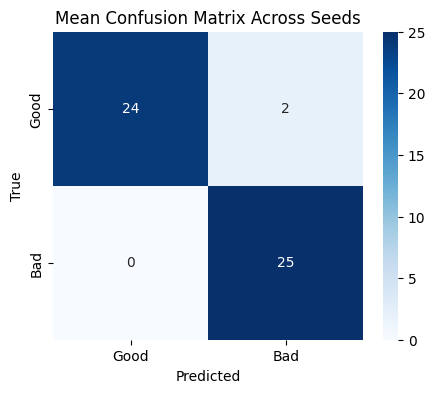

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(avg_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Mean Confusion Matrix Across Seeds")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0.5, 1.5], ["Good", "Bad"])
plt.yticks([0.5, 1.5], ["Good", "Bad"])
plt.show()


# Permutation Feature Importance


🔁 Permutation importance with seed 14
2/2 [==============================] - 1s 257ms/step

🔁 Permutation importance with seed 15
2/2 [==============================] - 0s 222ms/step

🔁 Permutation importance with seed 92
2/2 [==============================] - 0s 219ms/step

🔁 Permutation importance with seed 65
2/2 [==============================] - 0s 201ms/step

🔁 Permutation importance with seed 35
2/2 [==============================] - 0s 213ms/step

🔁 Permutation importance with seed 89
2/2 [==============================] - 0s 229ms/step

🔁 Permutation importance with seed 79
2/2 [==============================] - 0s 223ms/step

🔁 Permutation importance with seed 32
2/2 [==============================] - 0s 194ms/step

🔁 Permutation importance with seed 38
2/2 [==============================] - 0s 197ms/step

🔁 Permutation importance with seed 46
2/2 [==============================] - 0s 202ms/step

🔁 Permutation importance with seed 26
2/2 [==============================] - 0s

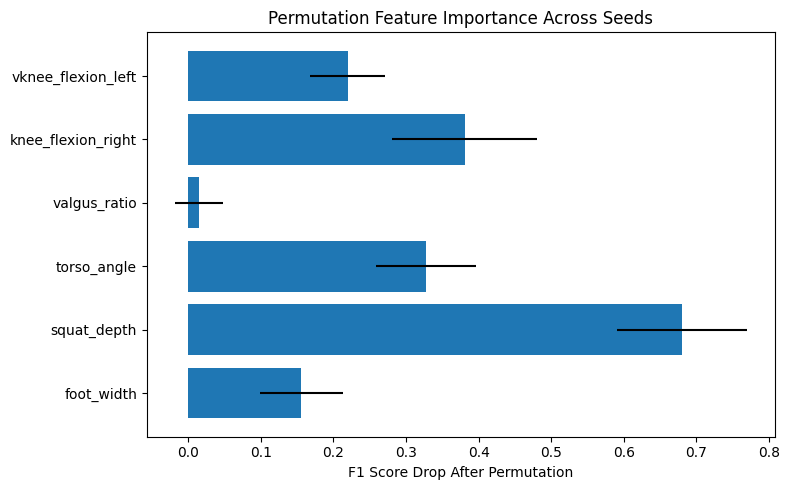

In [20]:
from sklearn.metrics import f1_score
# Your 6 feature names
feature_names = [
    "vknee_flexion_left",
    "knee_flexion_right",
    "valgus_ratio",
    "torso_angle",
    "squat_depth",
    "foot_width"
]


# Store F1 drops per feature across seeds
perm_importance = defaultdict(list)

for seed in seeds:
    print(f"\n🔁 Permutation importance with seed {seed}")
    set_seed(seed)

    # Recreate train/test split
    _, X_test, _, y_test = train_test_split(
        X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=seed
    )

    # Predict baseline F1
    y_pred_base = (model.predict(X_test).flatten() > 0.5).astype(int)
    baseline_f1 = f1_score(y_test, y_pred_base)

    for i, feature_name in enumerate(feature_names):
        X_permuted = X_test.copy()

        # Shuffle i-th feature across time dimension for each sample
        for sample in X_permuted:
            np.random.shuffle(sample[:, i])

        y_pred_perm = (model.predict(X_permuted).flatten() > 0.5).astype(int)
        permuted_f1 = f1_score(y_test, y_pred_perm)
        drop = baseline_f1 - permuted_f1

        perm_importance[feature_name].append(drop)

# Summarize results
print("\n📊 Mean ± Std F1 Drop (Permutation Importance):")
for name in feature_names:
    drops = perm_importance[name]
    print(f"{name:<25}: {np.mean(drops):.4f} ± {np.std(drops):.4f}")

# Plot averaged importance
mean_drops = [np.mean(perm_importance[name]) for name in feature_names]
std_drops = [np.std(perm_importance[name]) for name in feature_names]

plt.figure(figsize=(8, 5))
plt.barh(feature_names, mean_drops, xerr=std_drops)
plt.xlabel("F1 Score Drop After Permutation")
plt.title("Permutation Feature Importance Across Seeds")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()